
#  Real Estate Market Analysis - Data Cleaning & EDA
Pulls scraped listing data from MySQL (`real_estate_db.properties`),
cleans it, engineers features, and explores it.



In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from getpass import getpass

sns.set_style("whitegrid")



# ## 1. Connect to MySQL and load the data


In [2]:

password = getpass("MySQL password for user 'root': ")

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password=password,
    database="real_estate_db",
)

df = pd.read_sql("SELECT * FROM properties", conn)
conn.close()

print(f"Loaded {len(df)} rows")
df.head()

Loaded 1176 rows


C:\Users\dec52\AppData\Local\Temp\ipykernel_20724\389212378.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM properties", conn)


,id,property_id,city,price_raw,price_numeric,area_raw,bhk,location,property_type,latitude,longitude,url,date_scraped
0,1,10401363,Chandigarh,₹ 6 Cr,60000000.0,350 Sq.Yd.,NaN,"South Mullanpur, Chandigarh",Plot,30.8090,76.7279,https://www.squareyards.com/resale-350-sq-yd-p...,2026-07-12
1,2,10330872,Chandigarh,₹ 6.75 Cr,67500000.0,265 Sq.Yd.,6.0,"North Mullanpur, Chandigarh",Independent House,30.7968,76.7201,https://www.squareyards.com/resale-6-bhk-pooja...,2026-07-12
2,3,10344026,Chandigarh,₹ 11 Cr,110000000.0,250 Sq.Yd.,6.0,"Sector 44, Chandigarh",Independent House,30.7183,76.7523,https://www.squareyards.com/resale-6-bhk-pooja...,2026-07-12
3,4,10509526,Chandigarh,₹ 2.15 Cr,21500000.0,1050 Sq.Ft.,2.0,"Chandigarh Airport, Chandigarh",Apartment,30.6990,76.7559,https://www.squareyards.com/resale-2-bhk-serva...,2026-07-12
4,5,10435694,Chandigarh,₹ 1.58 Cr,15800000.0,2250 Sq.Ft.,3.0,"North Mullanpur, Chandigarh",Builder Floor,30.8537,76.6034,https://www.squareyards.com/resale-3-bhk-pooja...,2026-07-12


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1176 non-null   int64  
 1   property_id    1176 non-null   object 
 2   city           1176 non-null   object 
 3   price_raw      1176 non-null   object 
 4   price_numeric  1136 non-null   float64
 5   area_raw       1176 non-null   object 
 6   bhk            707 non-null    float64
 7   location       1176 non-null   object 
 8   property_type  1176 non-null   object 
 9   latitude       1176 non-null   float64
 10  longitude      1176 non-null   float64
 11  url            1176 non-null   object 
 12  date_scraped   1176 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 119.6+ KB


In [ ]:

# Quick sanity check - row count per city should match what you scraped
df["city"].value_counts()

city
Aligarh       410
Delhi         404
Chandigarh    362
Name: count, dtype: int64

# ## 2. Data Cleaning

In [6]:
# Check for duplicate listings (same property scraped twice, e.g. across
# overlapping pages if the site's ordering shifted mid-scrape)
print(f"Duplicate property_ids: {df['property_id'].duplicated().sum()}")
df = df.drop_duplicates(subset="property_id").reset_index(drop=True)
print(f"Rows after removing duplicates: {len(df)}")

Duplicate property_ids: 72
Rows after removing duplicates: 1104


In [7]:
# Parse area_raw ("1600 Sq.Ft." / "200 Sq.Yd.") into a numeric value + unit
df[["area_value", "area_unit"]] = df["area_raw"].str.extract(r"([\d.]+)\s*(Sq\.Ft\.|Sq\.Yd\.)")
df["area_value"] = pd.to_numeric(df["area_value"], errors="coerce")

df["area_unit"].value_counts()


area_unit
Sq.Ft.    809
Sq.Yd.    286
Name: count, dtype: int64

In [8]:
# Standardize everything to sq.ft (1 Sq.Yd. = 9 Sq.Ft.) so price_per_sqft
# is comparable across flats (usually Sq.Ft.) and plots (usually Sq.Yd.)
def to_sqft(row):
    if pd.isna(row["area_value"]):
        return np.nan
    if row["area_unit"] == "Sq.Yd.":
        return row["area_value"] * 9
    return row["area_value"]

df["area_sqft"] = df.apply(to_sqft, axis=1)

In [9]:
# Engineer price_per_sqft - the key derived feature for comparison
df["price_per_sqft"] = df["price_numeric"] / df["area_sqft"]

df[["city", "property_type", "price_numeric", "area_sqft", "price_per_sqft"]].describe()

,price_numeric,area_sqft,price_per_sqft
count,1.067000e+03,1.095000e+03,1.059000e+03
mean,3.222175e+07,8.837223e+03,1.771689e+04
std,1.189856e+08,2.266107e+05,6.360614e+04
min,3.261650e+05,1.000000e+02,1.000000e+00
25%,5.799500e+06,1.064000e+03,4.285149e+03
50%,1.000000e+07,1.641000e+03,7.621955e+03
75%,2.800000e+07,2.157500e+03,1.666667e+04
max,3.150000e+09,7.500000e+06,1.702703e+06


In [10]:
# How many listings have a usable price? ("Price on Request" listings
# will show up as NaN here - that's expected, not a bug)
print(f"Missing price_numeric: {df['price_numeric'].isna().sum()} of {len(df)}")
print(f"Missing area_sqft: {df['area_sqft'].isna().sum()} of {len(df)}")

Missing price_numeric: 37 of 1104
Missing area_sqft: 9 of 1104


In [11]:

# Keep these rows for count/location analysis, but exclude them from any
# price-based analysis via a separate clean subset
df_priced = df.dropna(subset=["price_numeric", "area_sqft"]).copy()
print(f"Rows usable for price analysis: {len(df_priced)}")


Rows usable for price analysis: 1059


In [12]:
# Note on missing 'bhk': this is expected and NOT a data quality issue -
# Aligarh listings are mostly plots, which have no BHK by definition.
print(f"Missing bhk: {df['bhk'].isna().sum()} of {len(df)}")
df.groupby("property_type")["bhk"].apply(lambda x: x.isna().mean())

Missing bhk: 412 of 1104


property_type
Apartment            0.022422
Builder Floor        0.017241
Independent House    0.054795
Penthouse            0.000000
Plot                 1.000000
Villa                0.000000
Name: bhk, dtype: float64

In [13]:
# Outlier check on price_per_sqft using the IQR method
Q1 = df_priced["price_per_sqft"].quantile(0.25)
Q3 = df_priced["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df_priced[(df_priced["price_per_sqft"] < lower) | (df_priced["price_per_sqft"] > upper)]
print(f"Potential outliers by price_per_sqft: {len(outliers)} of {len(df_priced)}")
outliers[["city", "property_type", "price_raw", "area_raw", "price_per_sqft"]] \
    .sort_values("price_per_sqft", ascending=False).head(10)

Potential outliers by price_per_sqft: 77 of 1059


,city,property_type,price_raw,area_raw,price_per_sqft
600,Delhi,Builder Floor,₹ 315 Cr,1850 Sq.Ft.,1.702703e+06
44,Chandigarh,Independent House,₹ 97 Cr,2000 Sq.Ft.,4.850000e+05
160,Chandigarh,Independent House,₹ 23.5 Cr,528 Sq.Ft.,4.450758e+05
130,Chandigarh,Independent House,₹ 85 Cr,2000 Sq.Ft.,4.250000e+05
40,Chandigarh,Independent House,₹ 42 Cr,1100 Sq.Ft.,3.818182e+05
187,Chandigarh,Independent House,₹ 45 Cr,1200 Sq.Ft.,3.750000e+05
402,Delhi,Builder Floor,₹ 6 Cr,200 Sq.Ft.,3.000000e+05
635,Delhi,Builder Floor,₹ 3 Cr,100 Sq.Ft.,3.000000e+05
424,Delhi,Plot,₹ 22 Cr,900 Sq.Ft.,2.444444e+05
488,Delhi,Builder Floor,₹ 4.25 Cr,200 Sq.Ft.,2.125000e+05


In [18]:

# %%
# Pull the listing URL for the single most extreme row - open it in a
# browser and manually check if the actual listed price looks like a typo
extreme = df_priced.loc[df_priced["price_per_sqft"].idxmax()]
print(extreme[["city", "property_type", "price_raw", "area_raw", "price_per_sqft", "url","property_id"]])

city                                                     Chandigarh
property_type                                     Independent House
price_raw                                                   ₹ 97 Cr
area_raw                                                2000 Sq.Ft.
price_per_sqft                                             485000.0
url               https://www.squareyards.com/resale-6-bhk-pooja...
property_id                                                10457468
Name: 44, dtype: object


In [17]:

# %%
# Once you've checked it manually: if it's confirmed bad data, drop just
# this one row (by its property_id) rather than the whole outlier set.
# Uncomment and fill in the real property_id after checking:
 
bad_id = "10458367"
df_priced = df_priced[df_priced["property_id"] != bad_id]
df = df[df["property_id"] != bad_id]
 


# ## 3. Exploratory Data Analysis 

# ### 3.1 Price per sqft distribution

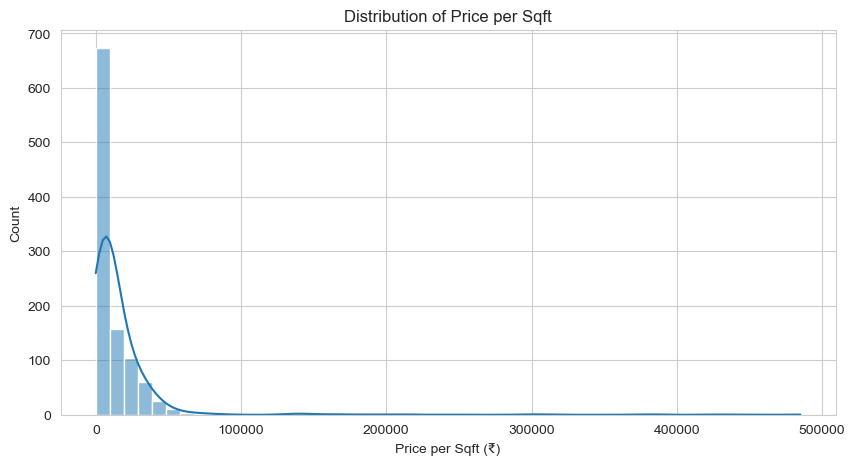

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(df_priced["price_per_sqft"], bins=50, kde=True)
plt.title("Distribution of Price per Sqft")
plt.xlabel("Price per Sqft (₹)")
plt.show()

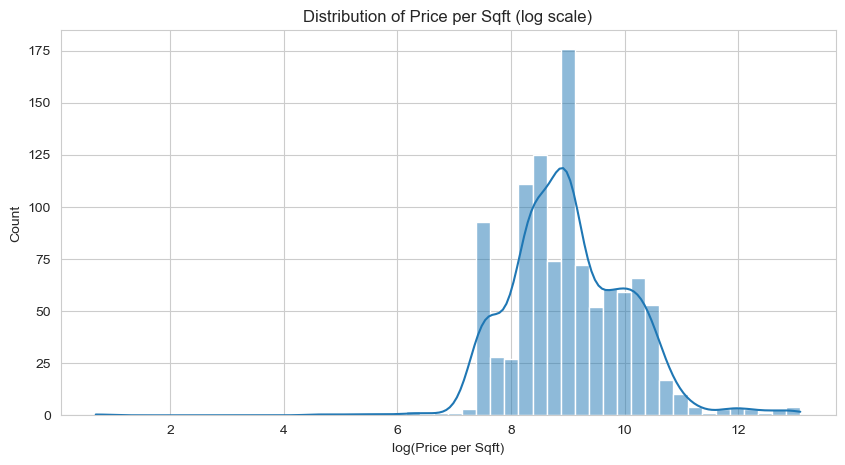

In [20]:
# Price is right-skewed (normal for real estate - a few very expensive
# properties stretch the tail). Log scale often shows the true shape better.
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df_priced["price_per_sqft"]), bins=50, kde=True)
plt.title("Distribution of Price per Sqft (log scale)")
plt.xlabel("log(Price per Sqft)")
plt.show()

# ### 3.2 Price per sqft by city

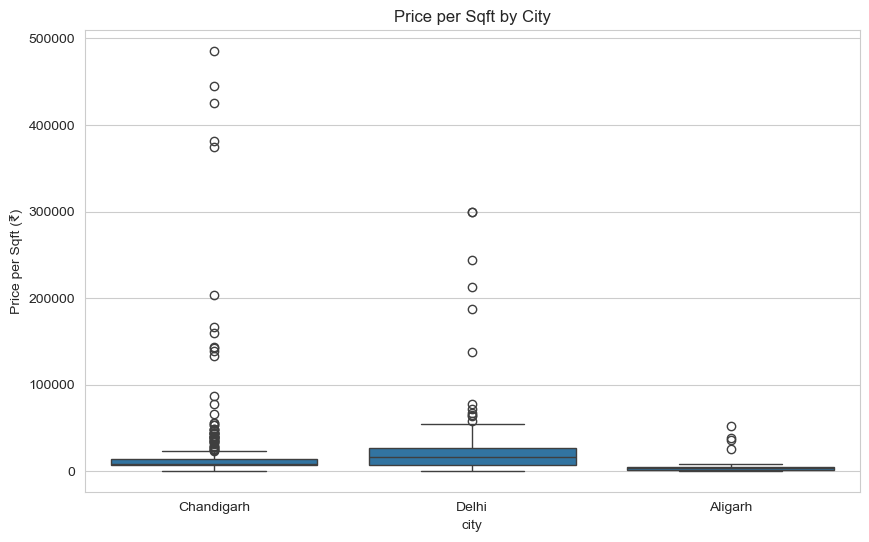

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_priced, x="city", y="price_per_sqft")
plt.title("Price per Sqft by City")
plt.ylabel("Price per Sqft (₹)")
plt.show()
 

In [22]:
df_priced.groupby("city")["price_per_sqft"] \
    .agg(["mean", "median", "count"]) \
    .sort_values("median", ascending=False)
 

,mean,median,count
city,,,
Delhi,21638.590745,16666.666667,377
Chandigarh,21712.117604,8395.230810,354
Aligarh,3717.567296,3571.000000,327


# ### 3.3 Price per sqft by property type

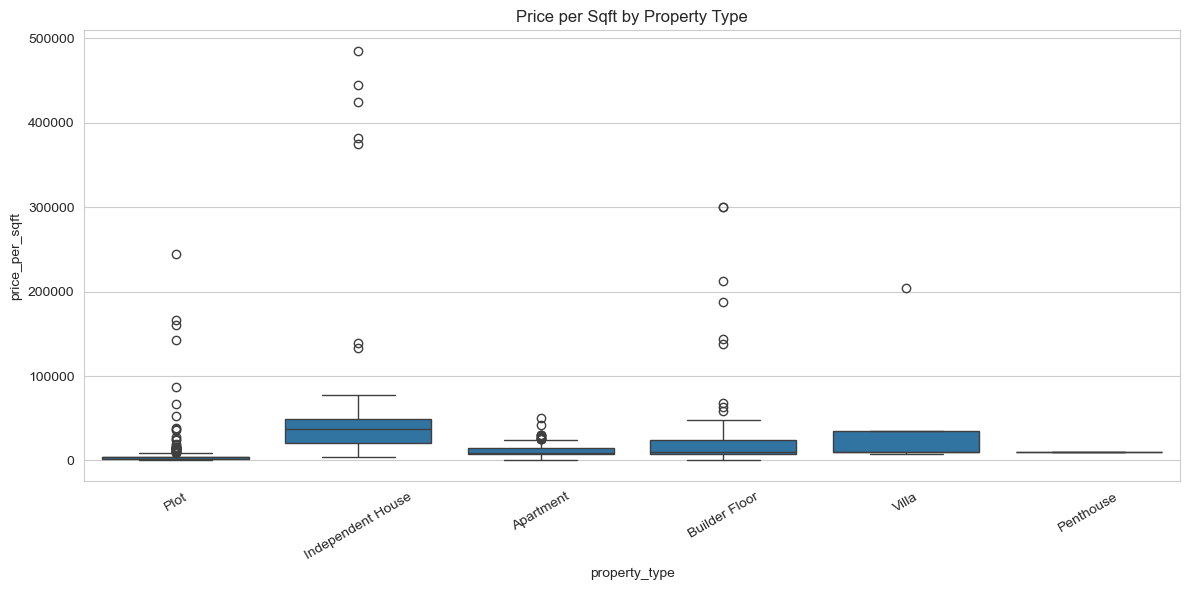

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_priced, x="property_type", y="price_per_sqft")
plt.xticks(rotation=30)
plt.title("Price per Sqft by Property Type")
plt.tight_layout()
plt.show()
 

# ### 3.4 Price per sqft by BHK
(Plots have no BHK, so this naturally only covers flats/houses)
 

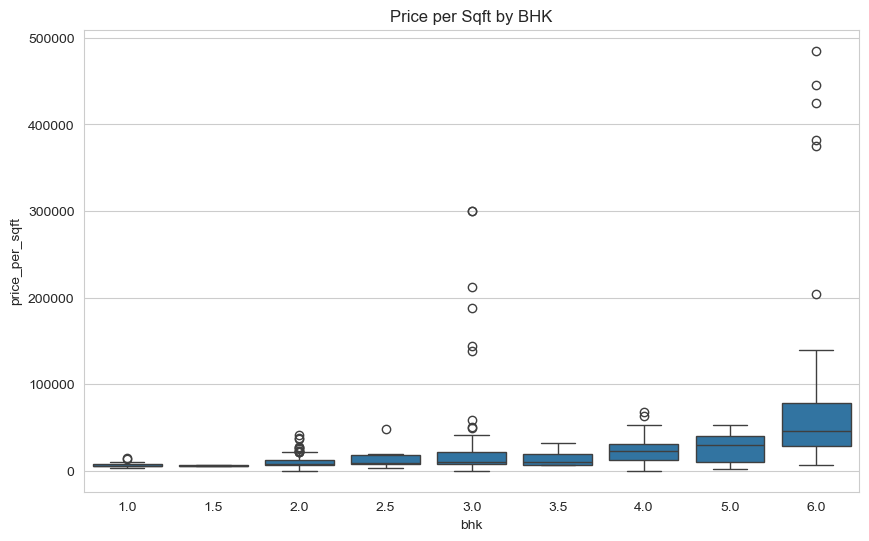

In [24]:
bhk_data = df_priced.dropna(subset=["bhk"])
plt.figure(figsize=(10, 6))
sns.boxplot(data=bhk_data, x="bhk", y="price_per_sqft")
plt.title("Price per Sqft by BHK")
plt.show()
 

# ### 3.5 Correlation heatmap

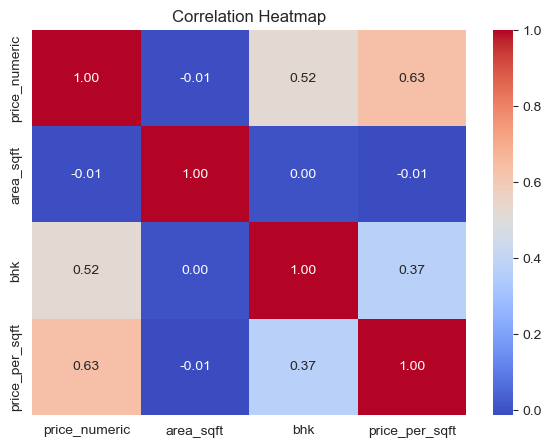

In [25]:
numeric_cols = ["price_numeric", "area_sqft", "bhk", "price_per_sqft"]
corr = df_priced[numeric_cols].corr()
 
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
 

# ### 3.6 Most expensive & most affordable neighborhoods
(Restricted to localities with at least 3 listings, so a single
expensive/cheap outlier listing can't distort the ranking)
 

In [26]:
locality_stats = (
    df_priced.groupby(["city", "location"])["price_per_sqft"]
    .agg(["mean", "count"])
    .query("count >= 3")
    .sort_values("mean", ascending=False)
)
 
print("Top 10 most expensive neighborhoods:")
locality_stats.head(10)
 

Top 10 most expensive neighborhoods:


mean  count
city       location                                       
Chandigarh Sector 9, Chandigarh       321851.851852      3
           Sector 7, Chandigarh       214397.461331      4
Delhi      New Rajinder Nagar, Delhi   83894.444444      5
           Kirti Nagar, Delhi          80847.975883      3
Chandigarh Sector 8, Chandigarh        80000.000000      4
Delhi      Shivalik Colony, Delhi      63518.518519      6
           Saket, Delhi                47133.680556      8
           Anand Niketan, Delhi        41169.626043      6
           Greater Kailash I, Delhi    40380.864438     14
           Navjeevan Vihar, Delhi      36685.516130      3

In [27]:
print("Top 10 most affordable neighborhoods:")
locality_stats.sort_values("mean").head(10)
 

Top 10 most affordable neighborhoods:


mean  count
city       location                                         
Aligarh    Tappal, Aligarh                2401.044697    149
           Sujanpur, Aligarh              4082.888889     12
Delhi      Mehrauli, Delhi                4120.833333      8
Chandigarh Central Derabassi, Chandigarh  4458.734821      9
Aligarh    Jattari, Aligarh               4913.958454    159
Chandigarh KharaR-Banur Road, Chandigarh  5025.521320      3
Delhi      Rajpur Khurd Extension, Delhi  5751.870656      6
           Uttam Nagar West, Delhi        6095.473251      3
Chandigarh Bir Chhat, Chandigarh          6255.427669     10
Delhi      Uttam Nagar, Delhi             6282.949025      9

# ### 3.7 Property type mix by city
This is where Aligarh's plot-heavy market vs. Delhi/Chandigarh's
flat-heavy markets should show up clearly.
 

In [28]:
type_mix = pd.crosstab(df["city"], df["property_type"], normalize="index") * 100
type_mix.round(1)
 

property_type,Apartment,Builder Floor,Independent House,Penthouse,Plot,Villa
city,,,,,,
Aligarh,0.0,0.0,0.3,0.0,99.7,0.0
Chandigarh,43.3,27.5,16.9,0.3,10.7,1.4
Delhi,17.5,77.9,3.0,0.0,1.5,0.0


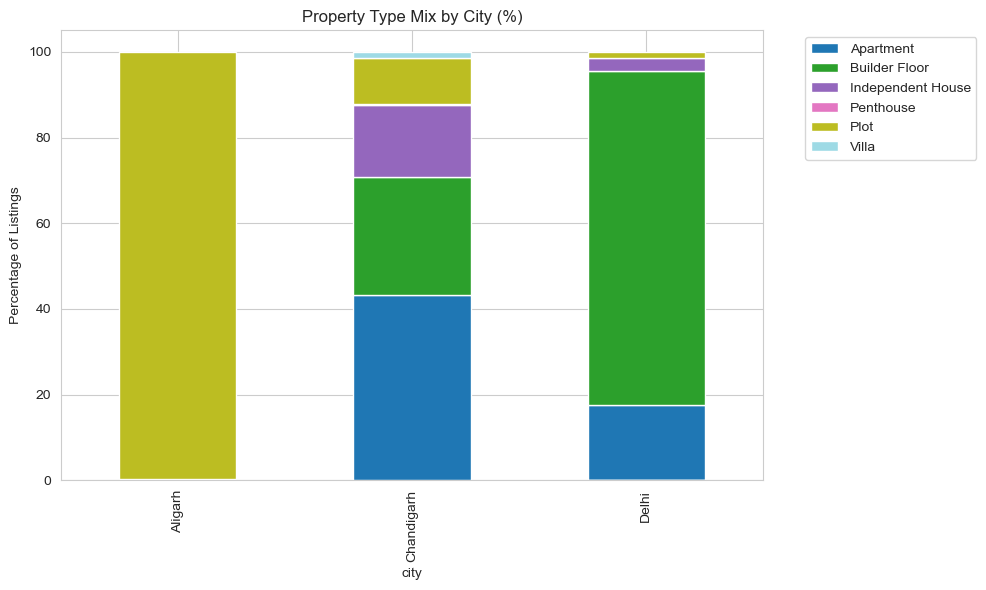

In [29]:
type_mix.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Property Type Mix by City (%)")
plt.ylabel("Percentage of Listings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ### 3.8 Segmented correlation - does area matter within each property type?
The pooled heatmap showed almost no area-price relationship, which is
suspicious since bigger properties should generally cost more. Checking
correlation separately per property type reveals whether that's a real
finding, or just different property types (tiny flats, huge plots) being
pooled together and canceling out a real within-type relationship.

In [30]:
segment_stats = df_priced.groupby("property_type").apply(
    lambda g: pd.Series({
        "count": len(g),
        "area_vs_price_corr": g["area_sqft"].corr(g["price_numeric"]),
        "area_vs_price_per_sqft_corr": g["area_sqft"].corr(g["price_per_sqft"]),
    })
).sort_values("count", ascending=False)
 
segment_stats

c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\dec52\AppData\Local\Temp\ipykernel_20724\1179339984.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_stats = df_priced.groupby("property_type").apply(


,count,area_vs_price_corr,area_vs_price_per_sqft_corr
property_type,,,
Builder Floor,393.0,0.315724,-0.024909
Plot,368.0,0.203869,-0.137033
Apartment,221.0,-0.042577,-0.110412
Independent House,70.0,0.605090,-0.079416
Villa,5.0,0.269580,-0.669514
Penthouse,1.0,NaN,NaN


Treat correlations for very small groups (e.g. Penthouse, Villa - likely
under ~10 listings each) with caution; too few points for a real conclusion.
Focus on Apartment, Builder Floor, Independent House, and Plot, which have
enough listings to trust.

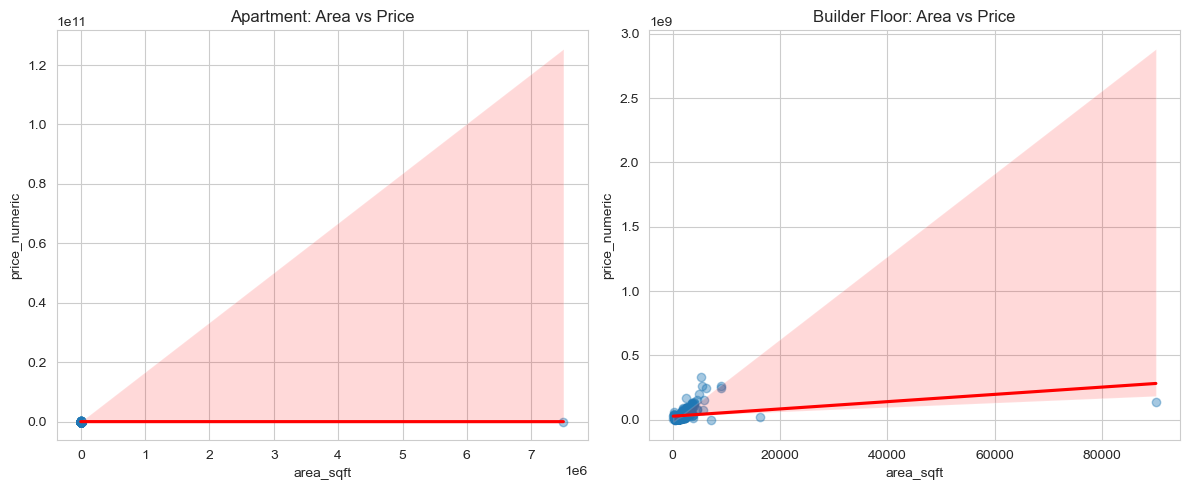

In [31]:
# Visualize area vs price for the two largest, most reliable segments
plt.figure(figsize=(12, 5))
for i, ptype in enumerate(["Apartment", "Builder Floor"]):
    plt.subplot(1, 2, i + 1)
    subset = df_priced[df_priced["property_type"] == ptype]
    sns.regplot(data=subset, x="area_sqft", y="price_numeric",
                scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    plt.title(f"{ptype}: Area vs Price")
plt.tight_layout()
plt.show()

# ### 3.9 Area outliers
 The Apartment scatter above shows a single absurd area value (axis running
 to 7 million sqft) compressing the whole chart into a flat line near zero -
 the same "one bad row" pattern as the earlier price outlier. Let's find
 and check it before trusting the segmented correlations.

In [41]:
df_priced[df_priced["property_type"] == "Apartment"] \
    .sort_values("area_sqft", ascending=False)[
        ["property_id", "city", "area_raw", "area_sqft", "price_raw", "url"]
    ].head(5)

,property_id,city,area_raw,area_sqft,price_raw,url
30,10278983,Chandigarh,5007 Sq.Ft.,5007.0,₹ 4.04 Cr,https://www.squareyards.com/resale-4-bhk-extra...
15,10382468,Chandigarh,500 Sq.Yd.,4500.0,₹ 11 Cr,https://www.squareyards.com/resale-4-bhk-pooja...
148,9891120,Chandigarh,4450 Sq.Ft.,4450.0,₹ 4.1 Cr,https://www.squareyards.com/resale-4-bhk-pooja...
9,10276751,Chandigarh,4390 Sq.Ft.,4390.0,₹ 4.75 Cr,https://www.squareyards.com/resale-5-bhk-serva...
55,10339972,Chandigarh,4276 Sq.Ft.,4276.0,₹ 5.9 Cr,https://www.squareyards.com/resale-4-bhk-pooja...


Open the top row's `url` in a browser and check the actual listed area.
If it's confirmed bad data (a parsing slip or a genuine site typo), drop
it the same way as the price outlier:

In [40]:
bad_area_id = "10487115"
df_priced = df_priced[df_priced["property_id"] != bad_area_id]
df = df[df["property_id"] != bad_area_id]

In [42]:
# %%
# Re-run the segmented correlation after dropping it, to see if Apartment's
# correlation looks more like a real positive relationship now
segment_stats_v2 = df_priced.groupby("property_type").apply(
    lambda g: pd.Series({
        "count": len(g),
        "area_vs_price_corr": g["area_sqft"].corr(g["price_numeric"]),
    })
).sort_values("count", ascending=False)
 
segment_stats_v2

c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\dec52\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\dec52\AppData\Local\Temp\ipykernel_20724\1025083255.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_stats_v2 = df_priced.groupby("property_type").apply(


,count,area_vs_price_corr
property_type,,
Builder Floor,393.0,0.315724
Plot,368.0,0.203869
Apartment,219.0,0.707837
Independent House,70.0,0.605090
Villa,5.0,0.269580
Penthouse,1.0,NaN



# ## 4. Key Findings

 1. **Chandigarh's average is misleading.** Its mean price/sqft
    (~₹21,700) is almost identical to Delhi's, but its median is less than
    half of Delhi's (~₹8,400 vs ~₹16,700). A small cluster of ultra-premium
    independent houses (Sectors 7-9) drags the mean up, so a *typical*
    Chandigarh property is actually much cheaper than a typical Delhi one.

 2. **Each city has a distinct property-type personality.** Aligarh is
    almost entirely plots (99.7%), Delhi is dominated by builder floors
    (78%), and Chandigarh has the most balanced mix (apartments, floors,
    houses, and plots all represented).

 3. **Area predicts price strongly, but only within a property type.**
    Pooled across all types, area barely correlated with price. Segmented
    by property type, apartments show the strongest relationship (0.71,
    after removing two bad outlier rows), while plot pricing is driven
    more by location than raw size (0.20).

 4. **Higher BHK correlates with higher price per sqft, not lower** -
    likely because larger-BHK listings skew toward premium independent
    houses rather than reflecting a bulk discount on standard flats.

 (Tweak the wording above before finalizing the README / dashboard.)
 


# ## 5. Export cleaned data for Power BI

In [43]:
df.to_csv("cleaned_properties.csv", index=False)
print(f"Saved {len(df)} cleaned rows to cleaned_properties.csv")
 

Saved 1101 cleaned rows to cleaned_properties.csv
